 Visualization saved as: accident_factors_importance.png


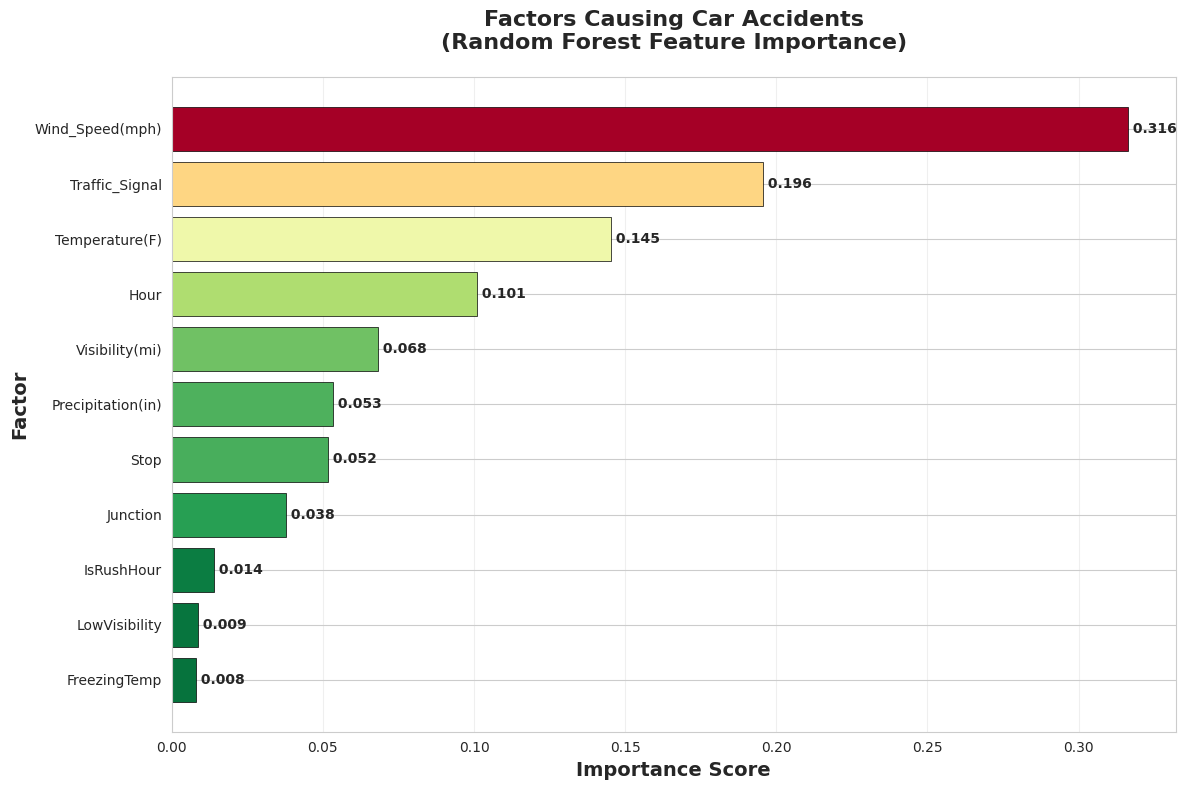

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('sample_data_for_github.csv')
df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed', errors='coerce')
df['Hour'] = df['Start_Time'].dt.hour
df['IsRushHour'] = (df['Hour'].between(7, 9) | df['Hour'].between(16, 19)).astype(int)

for col in ['Amenity', 'Bump', 'Crossing', 'Junction', 'Stop', 'Traffic_Signal']:
    if col in df.columns:
        df[col] = df[col].astype(str).isin(['True', '1', 'true']).astype(int)

num_cols = ['Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

df['HighSeverity'] = (df['Severity'] >= 3).astype(int)
df['LowVisibility'] = (df['Visibility(mi)'] < 5).astype(int)
df['FreezingTemp'] = (df['Temperature(F)'] < 32).astype(int)

features = ['Temperature(F)', 'Visibility(mi)', 'Wind_Speed(mph)',
            'Precipitation(in)', 'Hour', 'IsRushHour', 'Junction',
            'Stop', 'Traffic_Signal', 'LowVisibility', 'FreezingTemp']

X = df[features].fillna(0)
y = df['HighSeverity']

rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X, y)

importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(12, 8))

colors = plt.cm.RdYlGn_r(importance['Importance'] / importance['Importance'].max())
ax.barh(importance['Feature'], importance['Importance'], color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Importance Score', fontsize=14, fontweight='bold')
ax.set_ylabel('Factor', fontsize=14, fontweight='bold')
ax.set_title('Factors Causing Car Accidents\n(Random Forest Feature Importance)',
             fontsize=16, fontweight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

for i, (_, row) in enumerate(importance.iterrows()):
    ax.text(row['Importance'], i, f" {row['Importance']:.3f}",
            va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('accident_factors_importance.png', dpi=300, bbox_inches='tight')
print(" Visualization saved as: accident_factors_importance.png")
plt.show()